In [1]:
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
import xtrack as xt
import xobjects as xo
import xpart as xp
import xcoll as xc

In [2]:
def install_errors(line, error_variant_name: str) -> None:
    env = line.env
    error_variants = {
        "dipole_b3":               [0, 0, 1, 0, 0, 0],
        "dipole_b5":               [0, 0, 0, 0, 1, 0],
        "dipole_b3b5":             [0, 0, 1, 0, 1, 0],
        "quadrupole_b4":           [0, 0, 0, 1, 0, 0],
        "quadrupole_b6":           [0, 0, 0, 0, 0, 1],
        "quadrupole_b4b6":         [0, 0, 0, 1, 0, 1],
        "dipole_b3_quadrupole_b4": [0, 0, 1, 1, 0, 0],
        "all":                     [0, 0, 1, 1, 1, 1],
    }
    b1, b2, b3, b4, b5, b6 = error_variants[error_variant_name]
    tte = env.elements.get_table()
    mask_rbends = tte.element_type == "RBend"
    mask_quads  = tte.element_type == "Quadrupole"

    mba = tte.rows[mask_rbends].rows["mba.*"].name
    mbb = tte.rows[mask_rbends].rows["mbb.*"].name
    qf  = tte.rows[mask_quads].rows["qf.*"].name
    qd  = tte.rows[mask_quads].rows["qd.*"].name

    env.vars["qph_setvalue"] = 0.0
    env.vars["qpv_setvalue"] = 0.0

    for nn in mba:
        env[nn].knl = np.array([b1*0., b2*0., b3*2.12e-3,   b4*0.,       b5*-5.74,  b6*0.])
    for nn in mbb:
        env[nn].knl = np.array([b1*0., b2*0., b3*-3.19e-3,  b4*0.,       b5*-5.10,  b6*0.])
    for nn in qf:
        env[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*0.75e-1,  b5*0.,     b6*-0.87e3])
    for nn in qd:
        env[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*-2.03e-1, b5*0.,     b6*2.04e3])

In [3]:
error_variants = {
    'dipole_b3': [0, 0, 1, 0, 0, 0],
    'dipole_b5': [0, 0, 0, 0, 1, 0],
    'dipole_b3b5': [0, 0, 1, 0, 1, 0],
    'quadrupole_b4': [0, 0, 0, 1, 0, 0],
    'quadrupole_b6': [0, 0, 0, 0, 0, 1],
    'quadrupole_b4b6': [0, 0, 0, 1, 0, 1],
    'dipole_b3_quadrupole_b4': [0, 0, 1, 1, 0, 0],
    'all': [0, 0, 1, 1, 1, 1]
}

In [4]:
line = xt.load('/Users/lisepauwels/phd/code/sps-xsuite-model/sps_with_aperture_inj_q20_beam_sagitta4.json')
env = line.env

cavity_elements, cavity_names = line.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line[name].frequency = 200e6
    line[name].lag = 180
    line[name].voltage = 0
# line['acl.31735'].voltage = 0 #setting 800 cav to 0V
line['actcse.31632'].voltage = 3.0e6

qx = 20.13
qy = 20.18
xi_x = 0.5
xi_y = 0.5

install_errors(line, 'all')
line.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"], step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=xi_x * qx, dqy=xi_y * qy, tol=1e-2, tag="chrom"),
        ],
    )
tw = line.twiss()

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           
                                             
Optimize - start penalty: 4.929                             
Matching: model call n. 8 penalty = 1.0245e-02              
Optimize - end penalty:  0.0102453                            


In [5]:
context = xo.ContextCpu()

In [155]:
num_particles  = 100
num_turns = 6000
sweep = 3000
nemitt_x = 2e-6
nemitt_y = 2e-6
sigma_z = 0.224
dico = {}
dico_part = {}
for plane in ['DPpos', 'DPneg']:

    line = xt.load('/Users/lisepauwels/phd/code/sps-xsuite-model/sps_with_aperture_inj_q20_beam_sagitta4.json')
    env = line.env

    cavity_elements, cavity_names = line.get_elements_of_type(xt.Cavity)
    for name in cavity_names:
        line[name].frequency = 200e6
        line[name].lag = 180
        line[name].voltage = 0
    # line['acl.31735'].voltage = 0 #setting 800 cav to 0V
    line['actcse.31632'].voltage = 3.0e6

    qx = 20.13
    qy = 20.18
    xi_x = 0.5
    xi_y = 0.5

    install_errors(line, 'all')
    line.match(
            method="6d",
            vary=[
                xt.VaryList(["kqf0", "kqd0"], step=1e-8, tag="quad"),
                xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4, tag="sext"),
            ],
            targets=[
                xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag="tune"),
                xt.TargetSet(dqx=xi_x * qx, dqy=xi_y * qy, tol=1e-2, tag="chrom"),
            ],
        )
    tw = line.twiss()

    #Params
    sweep = -abs(sweep) if plane == 'DPpos' else abs(sweep)

    #Generating the particles
    part = xp.generate_matched_gaussian_bunch(nemitt_x=nemitt_x,
                                            nemitt_y=nemitt_y,
                                            sigma_z=sigma_z, num_particles=num_particles, line=line)

    #Tracking
    line.discard_tracker()
    line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto'))
    rf_sweep = xc.RFSweep(line)
    rf_sweep.prepare(sweep_per_turn=sweep/num_turns)
    rf_sweep.info()

    line.scattering.enable()
    line.track(particles=part, num_turns=num_turns, time=True, with_progress=5, turn_by_turn_monitor=True)
    line.scattering.disable()

    mon = line.record_last_track
    dico[plane] = mon.to_dict()
    dico_part[plane] = {'x' : part.x.copy(), 'y': part.y.copy(),
                        'px': part.px.copy(), 'py': part.py.copy(),
                        'zeta': part.zeta.copy(), 'delta': part.delta.copy(),
                        'at_element': part.at_element.copy(), 'at_turn': part.at_turn.copy()}

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           
                                             
Optimize - start penalty: 4.929                             
Matching: model call n. 8 penalty = 1.0245e-02              
Optimize - end penalty:  0.0102453                            
*** Maximum RMS bunch length 0.23610110400434292m.
... distance to target bunch length: -2.2226e-01
... distance to target bunch length: 5.5784e-03
... distance to target bunch length: 5.2361e-03
... distance to target bunch length: -6.3267e-03
... distance to target bunch length: 1.9948e-03
... distance to target bunch length: -3.8258e-04
... distance to target bunch length: 5.3833e-05
... distance to target bunch length: 1.2594e-06
... distance to target bunch length: -1.0995e-10
... distance to target bunch length: 1.2805e-07
--> Bunch length: 0.22399999989004865
--> Emittance: 0.27971631543426534
Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...


...

Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.
Enabled time-dependent variables in the line.
The current frequency is 200000000.5Hz, adding 0.5Hz per turn.
This sweep will move the center of the bucket with Δδ = -1.394e-06 per turn.
The bucket height is 0.002982, so this implies the sweep will shift one bucket every 4278.21 turns.
No xcoll elements found in line.


Tracking:   0%|          | 0/6000 [00:00<?, ?it/s]

No xcoll elements found in line.


In [156]:
for plane in ['DPpos', 'DPneg']:
    for key in dico[plane]['data'].keys():
        if np.size(dico[plane]['data'][key]) == 6000*100:
            dico[plane]['data'][key] = dico[plane]['data'][key].reshape(100,6000)

In [118]:
def df_to_delta(df_hz: np.ndarray | float) -> np.ndarray | float:
    sps_gtr = 17.95
    sps_g0 = 27.643
    f0 = 200e6
    eta = 1 / sps_gtr**2 - 1 / sps_g0**2
    return -np.asarray(df_hz) / (f0 * eta)

In [160]:
for plane in ['DPpos', 'DPneg']:
    dico_part[plane]['element_names'] = []
    for idx in dico_part[plane]['at_element']:
        dico_part[plane]['element_names'].append(line.element_names[idx])

In [ ]:
plane = 'DPpos'
for nn in np.unique(dico_part['DPpos']['element_names']):
    print(nn, env.element_dict[nn])

sps$start Marker()
vcak.11101.a_aper LimitEllipse(a=0.0415, b=0.0415)
vcak.32501.a_aper LimitEllipse(a=0.0415, b=0.0415)
vcak.33501.a_aper LimitEllipse(a=0.0415, b=0.0415)
vcak.41101.a_aper LimitEllipse(a=0.0415, b=0.0415)
vcak.61101.a_aper LimitEllipse(a=0.0415, b=0.0415)
vcak.63501.a_aper LimitEllipse(a=0.0415, b=0.0415)
vtto.31105.a_aper LimitEllipse(a=0.0415, b=0.0415)


In [185]:
dico_part[plane]['x']

array([-0.04129036, -0.04134162, -0.04026143, -0.0415888 , -0.04070262,
       -0.04112702, -0.04033939, -0.0415101 , -0.0417778 , -0.04042105,
       -0.04155013, -0.04161105, -0.04102734, -0.0414167 , -0.0408418 ,
       -0.04161461, -0.04144186, -0.04145152, -0.04081896, -0.04152309,
       -0.04115538, -0.0413493 , -0.04139414, -0.04132147, -0.04143271,
       -0.04156605, -0.04167865, -0.04153634, -0.03946346, -0.04198405,
       -0.04157367, -0.04181035, -0.04142881, -0.04156404, -0.0400726 ,
       -0.0414296 , -0.04165193, -0.04135176, -0.04172406, -0.04153889,
       -0.04173909, -0.04094197, -0.04140275, -0.04164263, -0.04183536,
       -0.04155537, -0.04090598, -0.04080688, -0.04132011, -0.04155711,
       -0.04102478, -0.04160091, -0.03976705, -0.0385452 , -0.04157304,
       -0.04172554, -0.04170065, -0.04118734, -0.04152625, -0.04088671,
       -0.04163237, -0.04185178, -0.04165574, -0.04107459, -0.04180253,
       -0.04179845, -0.04143608, -0.04145873, -0.04149012, -0.04

In [191]:
np.unique(dico_part[plane]['element_names'], return_counts=True)

(array(['vcak.12501.a_aper', 'vcak.22501.a_aper', 'vcak.32501.a_aper',
        'vcak.52501.a_aper', 'vcak.62501.a_aper'], dtype='<U17'),
 array([ 7, 26,  9, 57,  1]))

In [189]:
tw.rows[np.unique(dico_part['DPpos']['element_names'])].dx

array([7.81224683, 4.6666385 , 4.65247924, 4.31544987, 4.68052861,
       4.80213875, 4.27791412, 4.78365733])

In [192]:
dico_part[plane]['delta'] * tw.rows['vcak.52501.a_aper'].dx

array([-0.03769292, -0.03713568, -0.03829876, -0.03769714, -0.03822137,
       -0.03905385, -0.03875759, -0.03555406, -0.03881431, -0.03974039,
       -0.0369464 , -0.03819775, -0.039689  , -0.03861003, -0.03856777,
       -0.03929715, -0.03856512, -0.04003348, -0.0393554 , -0.03898885,
       -0.03870616, -0.03961755, -0.03906916, -0.03858859, -0.03974484,
       -0.03877803, -0.03705075, -0.03965913, -0.0390903 , -0.03753983,
       -0.03871367, -0.03739023, -0.03653487, -0.0377531 , -0.03885614,
       -0.03896098, -0.03721109, -0.0389061 , -0.03830887, -0.03721454,
       -0.03913649, -0.03959146, -0.03984953, -0.038486  , -0.03757822,
       -0.03707787, -0.03897524, -0.03775273, -0.03848537, -0.03593939,
       -0.03871393, -0.03854649, -0.03849711, -0.03683615, -0.03781087,
       -0.03815291, -0.03833233, -0.03887584, -0.03901904, -0.0383398 ,
       -0.03789247, -0.03781756, -0.03852742, -0.03909936, -0.0383772 ,
       -0.03714614, -0.03963001, -0.03968438, -0.03626258, -0.03

This shows it should not be dispersion because you are very far from the aperture itself, now check if x position explodes

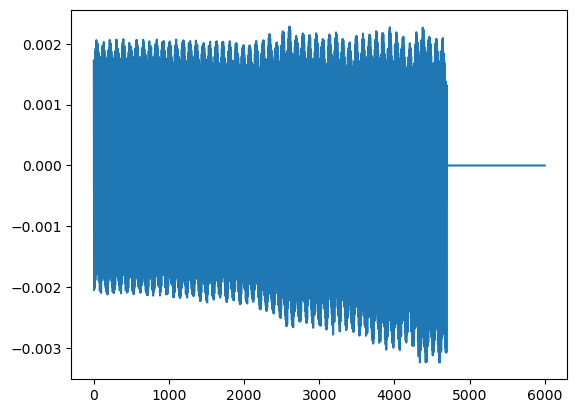

In [214]:
pid = 14
plt.plot(dico[plane]['data']['x'][pid,:] - tw.rows['qf.10010'].dx*dico[plane]['data']['delta'][pid,:])

In [198]:
tw.name

array(['sps$start', 'begi.10010', 'qf.10010', ..., 'end.10010', 'sps$end',
       '_end_point'], shape=(32539,), dtype=object)

# Plot tune diagrams

In [218]:
import sys
from pathlib import Path

In [226]:
from matplotlib.lines import Line2D

In [223]:
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "helper_functions"))
from tune_diagram import TuneDiagram, TuneMap

In [229]:
import pandas as pd

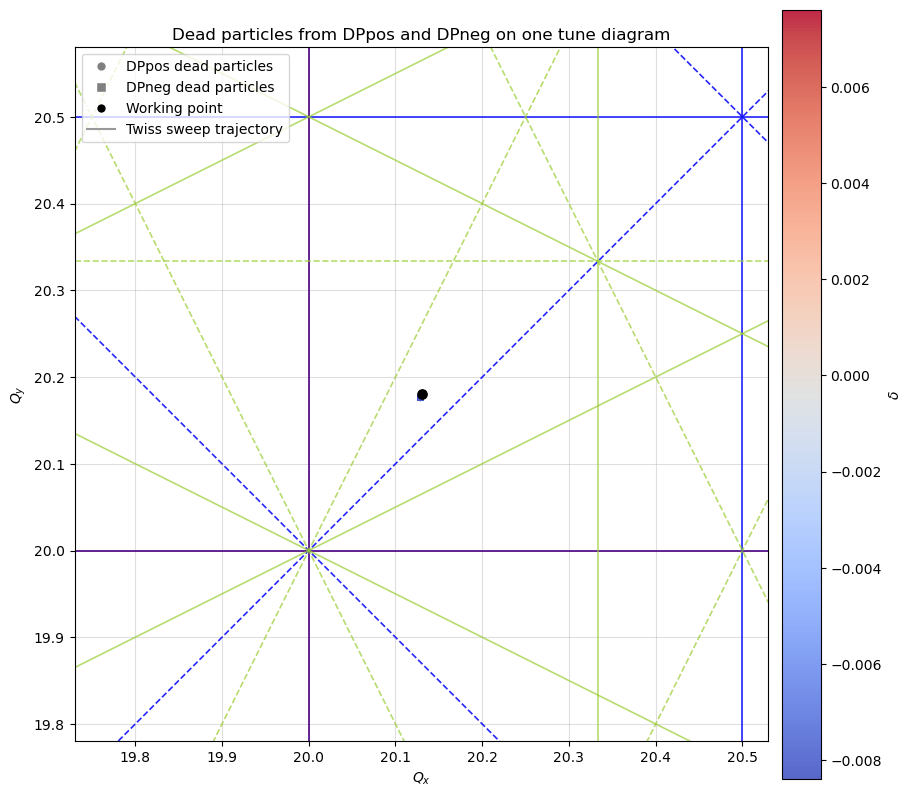

In [230]:
# ------------------------------------------------------------------
  # Imports from this repo
  # ------------------------------------------------------------------
REPO_ROOT = Path("/Users/lisepauwels/phd/code/sps-momentum-acceptance")
sys.path.insert(0, str(REPO_ROOT / "helper_functions"))

from tune_diagram import TuneDiagram

# ------------------------------------------------------------------
# Inputs you already have
# ------------------------------------------------------------------
# dico_part["DPpos"]["delta"]
# dico_part["DPneg"]["delta"]

# ------------------------------------------------------------------
# Build Qx(delta), Qy(delta) from the saved twiss scan
# ------------------------------------------------------------------
twiss_path = REPO_ROOT / "tests" / "sextupoles_off" / "twiss_delta_scans" / "q_vs_delta_pm1e2" / "twiss_q_vs_delta.parquet"
twiss_scan = pd.read_parquet(twiss_path).sort_values("delta")

delta_grid = twiss_scan["delta"].to_numpy(dtype=float)
qx_grid = twiss_scan["qx"].to_numpy(dtype=float)
qy_grid = twiss_scan["qy"].to_numpy(dtype=float)

# working point from delta = 0
i0 = int(np.argmin(np.abs(delta_grid)))
qx0 = float(qx_grid[i0])
qy0 = float(qy_grid[i0])

# ------------------------------------------------------------------
# Collect dead-particle deltas from both sweeps
# ------------------------------------------------------------------
delta_pos = np.asarray(dico_part["DPpos"]["delta"], dtype=float)
delta_neg = np.asarray(dico_part["DPneg"]["delta"], dtype=float)

all_delta = np.concatenate([delta_pos, delta_neg])

# clip to interpolation range
delta_pos_clip = np.clip(delta_pos, delta_grid.min(), delta_grid.max())
delta_neg_clip = np.clip(delta_neg, delta_grid.min(), delta_grid.max())

# map delta -> (Qx, Qy)
qx_pos = np.interp(delta_pos_clip, delta_grid, qx_grid)
qy_pos = np.interp(delta_pos_clip, delta_grid, qy_grid)

qx_neg = np.interp(delta_neg_clip, delta_grid, qx_grid)
qy_neg = np.interp(delta_neg_clip, delta_grid, qy_grid)

# ------------------------------------------------------------------
# Plot everything on one tune diagram
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)

td = TuneDiagram(qx0=qx0, qy0=qy0, half_range=0.4, max_order=3, skew=True)
td.plot(ax=ax, show_working_point=False)
ax.set_aspect("equal")

# background full sweep trajectory
ax.plot(qx_grid, qy_grid, color="0.6", lw=1.5, alpha=0.8, zorder=0)

# dead particles from positive sweep
sc = ax.scatter(
    qx_pos,
    qy_pos,
    c=delta_pos,
    cmap="coolwarm",
    vmin=all_delta.min(),
    vmax=all_delta.max(),
    s=18,
    marker="o",
    alpha=0.85,
    edgecolors="none",
    label="DPpos dead particles",
)

# dead particles from negative sweep
ax.scatter(
    qx_neg,
    qy_neg,
    c=delta_neg,
    cmap="coolwarm",
    vmin=all_delta.min(),
    vmax=all_delta.max(),
    s=18,
    marker="s",
    alpha=0.85,
    edgecolors="none",
    label="DPneg dead particles",
)

# working point
ax.scatter(qx0, qy0, color="black", s=45, zorder=5)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r"$\delta$")

handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=7, label="DPpos dead particles"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="gray", markersize=7, label="DPneg dead particles"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="black", markersize=7, label="Working point"),
    Line2D([0], [0], color="0.6", lw=1.5, label="Twiss sweep trajectory"),
]
ax.legend(handles=handles, loc="upper left", frameon=True)

ax.set_xlabel(r"$Q_x$")
ax.set_ylabel(r"$Q_y$")
ax.set_title("Dead particles from DPpos and DPneg on one tune diagram")

plt.show()

In [ ]:

# with open('outputs/data_saving_positions.json', 'w') as fid:
#     json.dump(dico, fid)
# with open('outputs/data_saving_positions_part.json', 'w') as fid:
#     json.dump(dico_part, fid)

TypeError: Object of type int64 is not JSON serializable

In [2]:
twiss_scan()

NameError: name 'twiss_scan' is not defined